## Example 6.5.1

$$ u'=e^{t-u\sin u}, \quad u(0)=0$$

In [22]:
using OrdinaryDiffEq
f(u, p, t) = exp(t - u * sin(u))
ivp = ODEProblem(f, 0, (0.0, 5.0))

ODEProblem with uType Int64 and tType Float64. In-place: false
Non-trivial mass matrix: false
timespan: (0.0, 5.0)
u0: 0

In [23]:
using FNCFunctions
t, u = FNC.rk23(ivp, 1e-5)
size(t)

(157,)

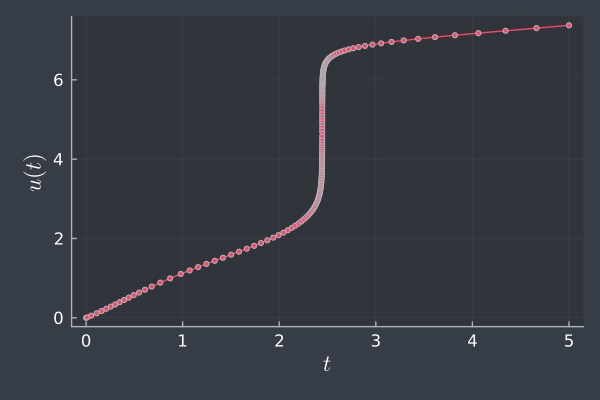

In [24]:
using Plots, LaTeXStrings
theme(:dark);  default(thickness_scaling=1.4)
plot(t, u, m=2, legend=false, xlabel=L"t", ylabel=L"u(t)")

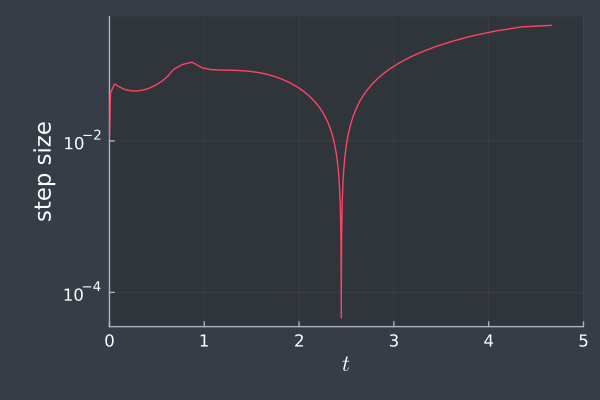

In [25]:
Δt = diff(t)
plot(t[1:end-1], Δt; legend=false,
    xaxis=(L"t", (0, 5)), yaxis=(:log10, "step size"))

In [26]:
minimum(Δt)

4.6096854609878335e-5

In [27]:
using Statistics
mean(Δt)

0.03205128205128205

## Example 6.5.2

$$ u'=(t+u)^2, \quad u(0)=1$$

In [28]:
using OrdinaryDiffEq, FNCFunctions
f(u, p, t) = (t + u)^2
ivp = ODEProblem(f, 1, (0.0, 1.0))
t, u = FNC.rk23(ivp, 1e-5);

┌ Warning: Stepsize too small near t=0.7854087204072808
└ @ FNCFunctions ~/.julia/packages/FNCFunctions/b44xn/src/chapter06.jl:102


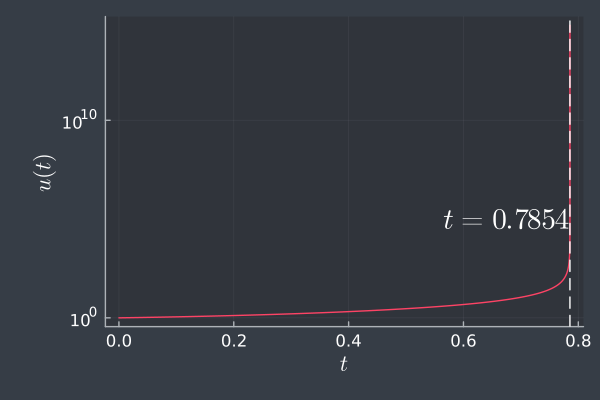

In [29]:
using Plots, LaTeXStrings, Printf
plot(t, u; legend=:none, xlabel=L"t",  yaxis=(:log10, L"u(t)"))

tf = t[end]
vline!([tf], l=(:dash, :white))
annotate!(tf, 1e5, (latexstring(@sprintf("t = %.4f ", tf)), :white), :right)